In [ ]:
# just unzipping the dataset
import zipfile

zip_path = "datasets.zip"
extract_path = "."

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped!")

Unzipped!


In [ ]:
#declaring paths to data
import re
import networkx as nx
from collections import deque

KB_PATH = "datasets/kb.txt"

QA_1HOP_TEST = "datasets/1-hop/qa_test.txt"
QA_2HOP_TEST = "datasets/2-hop/qa_test.txt"
QA_3HOP_TEST = "datasets/3-hop/qa_test.txt"

print("Imports OK")

Imports OK


In [ ]:
#similar to what we did in the notebook trans-e-v1 --> we just make a multidigraph, with both forward and inverse relations

import networkx as nx
import pandas as pd
from collections import Counter

def load_kb(path, add_inverse_edges=True):
    G = nx.MultiDiGraph()

    triples = []
    relation_list = []
    entity_list = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split("|")
            if len(parts) != 3:
                continue

            head, rel, tail = [p.strip() for p in parts]

            G.add_edge(head, tail, relation=rel)
            triples.append((head, rel, tail))

            relation_list.append(rel)
            entity_list.extend([head, tail])

            #adding inverse edges
            if add_inverse_edges:
                inv_rel = f"inv_{rel}"
                G.add_edge(tail, head, relation=inv_rel)
                triples.append((tail, inv_rel, head))

                relation_list.append(inv_rel)
                entity_list.extend([tail, head])

    triples_df = pd.DataFrame(triples, columns=["head", "relation", "tail"])

    entity_counts = Counter(entity_list)
    entity_df = pd.DataFrame(
        [{"entity": e, "degree_count": c} for e, c in entity_counts.items()]
    ).sort_values("degree_count", ascending=False)

    relation_counts = Counter(relation_list)
    relation_df = pd.DataFrame(
        [{"relation": r, "count": c} for r, c in relation_counts.items()]
    ).sort_values("count", ascending=False)

    return G, triples_df, entity_df, relation_df

In [ ]:
#just checking a local neighborhood to see that the inverse edges got added correctly
def plot_graph_sample(G, start_entity=None, radius=1, max_nodes=40, seed=42):
    import matplotlib.pyplot as plt
    import random

    random.seed(seed)

    if start_entity is not None and start_entity in G:
        nodes = nx.single_source_shortest_path_length(G, start_entity, cutoff=radius).keys()
        H = G.subgraph(list(nodes)).copy()
    else:
        edges = list(G.edges(data=True))
        sampled_edges = random.sample(edges, min(len(edges), max_nodes * 2))

        H = nx.DiGraph()
        for u, v, d in sampled_edges:
            H.add_edge(u, v, **d)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(H, seed=seed, k=0.8)

    nx.draw(H, pos,
            with_labels=True,
            node_size=700,
            font_size=8,
            arrows=True,
            alpha=0.8)

    edge_labels = nx.get_edge_attributes(H, "relation")
    nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=7)

    plt.title(f"{H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
    plt.axis("off")
    plt.show()

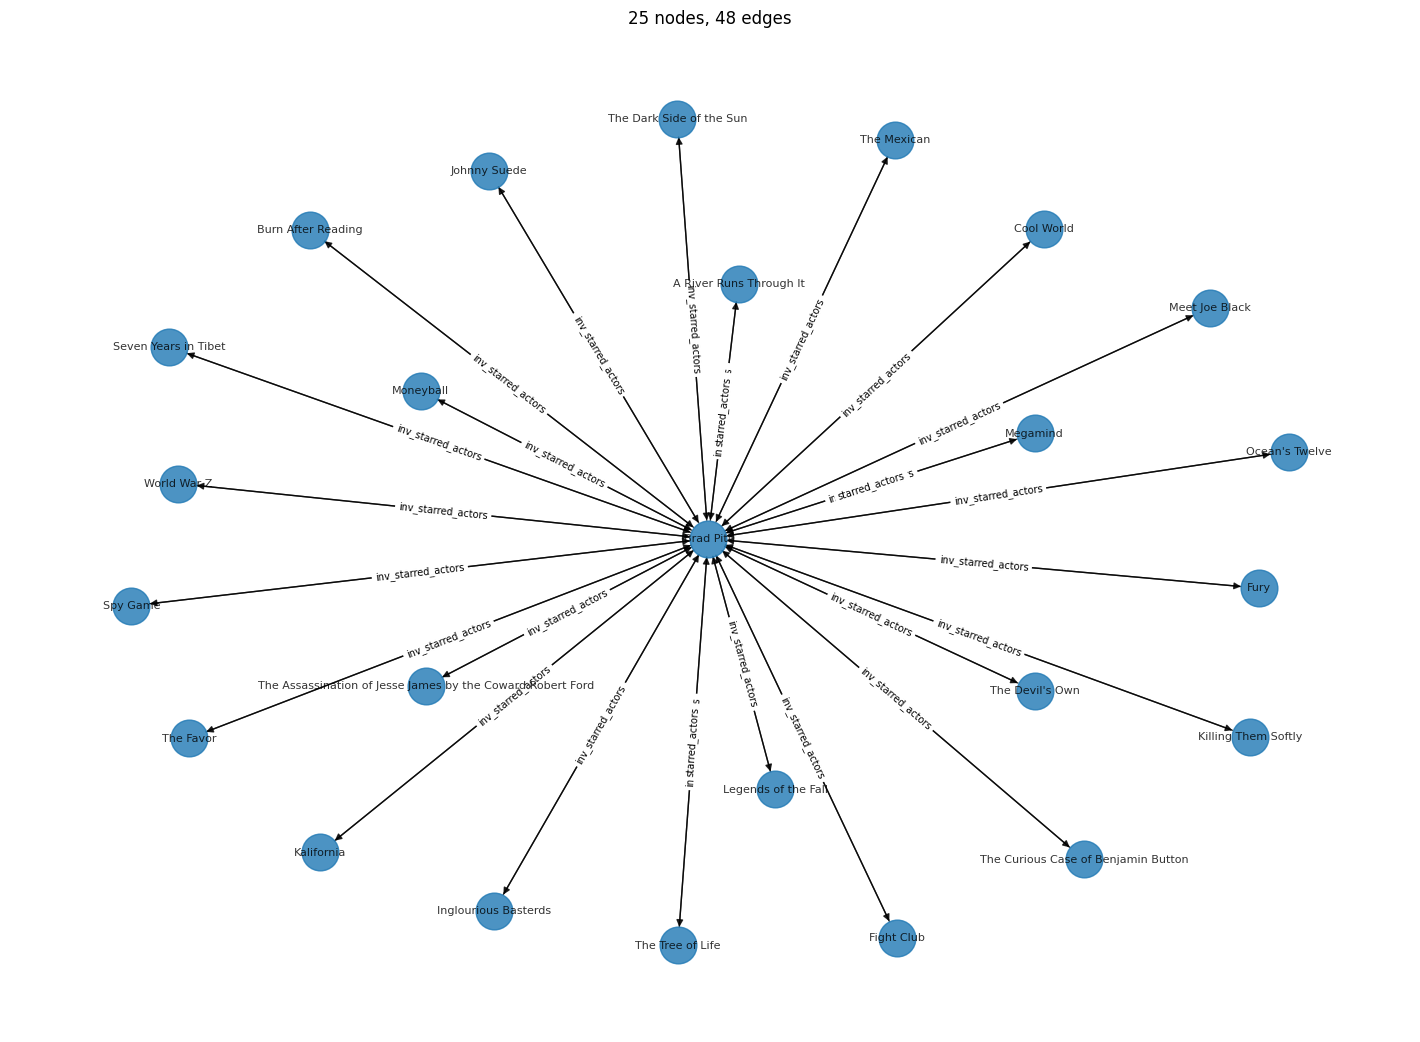

In [ ]:
#visualizing the neighborhood with the inverse edges
G, triples_df, entities_df, relations_df = load_kb(KB_PATH, add_inverse_edges=True)
plot_graph_sample(G, start_entity="Brad Pitt", radius=1)

In [ ]:
triples_df.head(5)

,head,relation,tail
0,Kismet,directed_by,William Dieterle
1,William Dieterle,inv_directed_by,Kismet
2,Kismet,written_by,Edward Knoblock
3,Edward Knoblock,inv_written_by,Kismet
4,Kismet,starred_actors,Marlene Dietrich


In [ ]:
entities_df.head(10)

,entity,degree_count
46,Drama,8608
52,Comedy,8010
119,Horror,2492
9,bd-r,2032
85,Action,1886
60,Thriller,1844
32,French,1572
61,Crime,1510
163,2009,1182
540,2007,1092


In [ ]:
relations_df.head(10)

,relation,count
4,starred_actors,33735
5,inv_starred_actors,33735
11,inv_has_tags,28944
10,has_tags,28944
3,inv_written_by,19543
2,written_by,19543
6,release_year,16726
7,inv_release_year,16726
1,inv_directed_by,15966
0,directed_by,15966


In [ ]:
#this time, we just save the test/train validation splits without any encoded labels, because we used the in built encoder that pykeen has
from pathlib import Path
from sklearn.model_selection import train_test_split

OUT_DIR = Path("transe_data")
OUT_DIR.mkdir(exist_ok=True)

train_df, temp_df = train_test_split(
    triples_df,
    test_size=0.1,
    random_state=42,
    shuffle=True,
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

train_df.to_csv(
    OUT_DIR / "train.tsv",
    sep="\t",
    header=False,
    index=False,
)

valid_df.to_csv(
    OUT_DIR / "valid.tsv",
    sep="\t",
    header=False,
    index=False,
)

test_df.to_csv(
    OUT_DIR / "test.tsv",
    sep="\t",
    header=False,
    index=False,
)

print("Saved PyKEEN files")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test:", len(test_df))

Saved PyKEEN files
Train: 242533
Valid: 13474
Test: 13475


In [ ]:
# same training loop as the one in the trans-e-v1 notebook, just using the in-built label encoder instead of us manually saving ids to json
import torch
from pykeen.pipeline import pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

result = pipeline(
    training="transe_data/train.tsv",
    validation="transe_data/valid.tsv",
    testing="transe_data/test.tsv",

    model="TransE",
    model_kwargs=dict(
        embedding_dim=100,
        scoring_fct_norm=1,
    ),

    optimizer="Adam",
    optimizer_kwargs=dict(
        lr=0.001,
    ),

    training_kwargs=dict(
        num_epochs=100,
        batch_size=4096,
    ),

    random_seed=42,
    device=device,
)

result.save_to_directory("transe_model")

print("Training complete!")

INFO:pykeen.utils:Using opt_einsum


CUDA available: True
Using device: cuda


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/59.0 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/59.0 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/59.0 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/13.3k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 9.63s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=43124, num_relations=18, create_inverse_triples=False, num_triples=240605, path="/content/transe_data/train.tsv") to file:///content/transe_model/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /content/transe_model


Training complete!


In [ ]:
# just evaluating the model before doing further experiments
# here the hits@10 basically means taht if we kept the top 10 scored tails, how likely are they to actually contain the gold candidate
# BUT --> the way pykeen ranks them is global, not just in the neighborhood
# so, when we say that hits@10 is 0.57, those 10 are out of the whole 40k entities, not just the neighbors
import pandas as pd

flat = result.metric_results.to_flat_dict()

rows = []

for key, value in flat.items():
    parts = key.split(".")

    rows.append({
        "side": parts[0] if len(parts) > 0 else None,
        "setting": parts[1] if len(parts) > 1 else None,
        "metric": ".".join(parts[2:]) if len(parts) > 2 else key,
        "value": value,
    })

metrics_df = pd.DataFrame(rows)

#display(metrics_df.head(20))

important = metrics_df[
    (metrics_df["setting"] == "realistic") &
    (metrics_df["metric"].isin([
        "mean_reciprocal_rank",
        "hits_at_1",
        "hits_at_3",
        "hits_at_10",
    ]))
]

display(important.sort_values(["metric", "side"]))

,side,setting,metric,value
176,both,realistic,hits_at_1,0.050813
174,head,realistic,hits_at_1,0.052612
175,tail,realistic,hits_at_1,0.049014
203,both,realistic,hits_at_10,0.577344
201,head,realistic,hits_at_10,0.573859
202,tail,realistic,hits_at_10,0.580829
185,both,realistic,hits_at_3,0.397662
183,head,realistic,hits_at_3,0.392490
184,tail,realistic,hits_at_3,0.402833


In [ ]:
# just checking vector dimensions and relation dimensions, because we want to do arithmetic with them
# basically we want to add them together to see the "translation" part of trans-E
import torch

model = result.model
tf = result.training

entity_to_id = tf.entity_to_id
relation_to_id = tf.relation_to_id

id_to_entity = {v: k for k, v in entity_to_id.items()}
id_to_relation = {v: k for k, v in relation_to_id.items()}

entity_embeddings = model.entity_representations[0]().detach().cpu()
relation_embeddings = model.relation_representations[0]().detach().cpu()

print("Done extracting")

print("Entity embeddings shape:", entity_embeddings.shape)
print("Relation embeddings shape:", relation_embeddings.shape)

print("\nSample entities:")
print(list(entity_to_id.items())[:10])

print("\nSample relations:")
print(list(relation_to_id.items())[:10])

Done extracting
Entity embeddings shape: torch.Size([43124, 100])
Relation embeddings shape: torch.Size([18, 100])

Sample entities:
[('$', 0), ('$9.99', 1), ("'71", 2), ("'Neath the Arizona Skies", 3), ("'R Xmas", 4), ("'Til There Was You", 5), ("'night, Mother", 6), ('(Untitled)', 7), ('+1', 8), ('...All the Marbles', 9)]

Sample relations:
[('directed_by', 0), ('has_genre', 1), ('has_imdb_rating', 2), ('has_imdb_votes', 3), ('has_tags', 4), ('in_language', 5), ('inv_directed_by', 6), ('inv_has_genre', 7), ('inv_has_imdb_rating', 8), ('inv_has_imdb_votes', 9)]


In [ ]:
# actually verifying the translation we mentioned in the previous cell
# just adding the heads and the relations, and chechking how close they are to the tails
# essentially just link prediction
import torch
import numpy as np

def evaluate_translation(test_df, n_samples=200):
    samples = test_df.sample(n_samples, random_state=42)

    ranks = []

    for _, row in samples.iterrows():
        h = row["head"]
        r = row["relation"]
        t = row["tail"]

        if h not in entity_to_id or r not in relation_to_id or t not in entity_to_id:
            continue

        h_id = entity_to_id[h]
        r_id = relation_to_id[r]
        t_id = entity_to_id[t]

        target = entity_embeddings[h_id] + relation_embeddings[r_id]

        distances = torch.norm(entity_embeddings - target, p=1, dim=1)
        sorted_ids = torch.argsort(distances)

        rank = (sorted_ids == t_id).nonzero(as_tuple=True)[0].item() + 1
        ranks.append(rank)

    ranks = np.array(ranks)

    print("Samples used:", len(ranks))
    print("Mean rank:", ranks.mean())
    print("Median rank:", np.median(ranks))
    print("Hits@1:", np.mean(ranks <= 1))
    print("Hits@10:", np.mean(ranks <= 10))
    print("Hits@50:", np.mean(ranks <= 50))

    return ranks

In [ ]:
import pandas as pd

test_triples_df = pd.read_csv(
    "transe_data/test.tsv",
    sep="\t",
    header=None,
    names=["head", "relation", "tail"],
)

print("Loaded test triples:", len(test_triples_df))
display(test_triples_df.head())

Loaded test triples: 13475


,head,relation,tail
0,Swedish,inv_in_language,Hotell
1,Humboldt County,starred_actors,Jeremy Strong
2,Horror,inv_has_genre,The Reef
3,Marlon Brando,inv_starred_actors,Apocalypse Now
4,Barry Levinson,inv_directed_by,The Bay


In [ ]:
evaluate_translation(test_triples_df, n_samples=200)

Samples used: 197
Mean rank: 861.5736040609137
Median rank: 9.0
Hits@1: 0.025380710659898477
Hits@10: 0.5076142131979695
Hits@50: 0.6903553299492385


array([   11,     2,    45,     2,     2,   133,     2,     2,     2,
          30,     2,     8,  3507,     2,     8, 34036,     6,   447,
           3,    52,   137,    19,  3327,     2, 10043,     2,     3,
          50,     3,    96,   133,    13, 17046,    22,    62,   328,
           5,   178,    43,     4,    10,    23,  2995,     2,     6,
          31,   829,     4,  1853,     1,   224,     4,     2,     5,
           2,    19,   396,    21,    19,   115,     4,   398,    87,
           7, 10080,   112,   169,  2149,  1992,     5,     7,     2,
           6,    23,   321,     2,     2,    27,     4,     2,     2,
         103,     9,    46,     5,     1,     2,     3,    19,  2699,
        1268,     3,     6,     3,     2,   171,     4,     2,    99,
          98,     3, 25019,     4,     9,   119,   130,    14,    11,
           3,    83,     2,   716,     3,     2,   480,   248,     3,
          41,     3,     6,     2,     1,    17,    41,  3701,     2,
           2,     1,

In [ ]:
# this is where we check the rank of the gold nodes, after we are done scoring them  with trans-E
# so the median of 2 just means that the second highest score, was usually the gold node
# mean will be pulled by extremes, so we went with median instead
# please note that this is just over a small subset of samples, not the entire set
import numpy as np
import pandas as pd
import torch

def evaluate_local_neighbor_ranking(test_df, G, n_samples=200):
    samples = test_df.sample(min(n_samples, len(test_df)), random_state=42)

    ranks = []
    skipped = 0
    rows = []

    for _, row in samples.iterrows():
        h = row["head"]
        r = row["relation"]
        t = row["tail"]

        if h not in entity_to_id or r not in relation_to_id or t not in entity_to_id:
            skipped += 1
            continue

        if h not in G:
            skipped += 1
            continue
        candidates = []
        for _, nbr, data in G.out_edges(h, data=True):
            if data["relation"] == r and nbr in entity_to_id:
                candidates.append(nbr)

        candidates = sorted(set(candidates))

        if t not in candidates:
            skipped += 1
            continue

        h_id = entity_to_id[h]
        r_id = relation_to_id[r]
        target = entity_embeddings[h_id] + relation_embeddings[r_id]

        cand_ids = torch.tensor([entity_to_id[c] for c in candidates])
        cand_embs = entity_embeddings[cand_ids]

        distances = torch.norm(cand_embs - target, p=1, dim=1)
        sorted_idx = torch.argsort(distances)

        ranked_candidates = [candidates[i] for i in sorted_idx.tolist()]
        rank = ranked_candidates.index(t) + 1

        ranks.append(rank)

        rows.append({
            "head": h,
            "relation": r,
            "gold_tail": t,
            "num_candidates": len(candidates),
            "local_rank": rank,
            "top_candidate": ranked_candidates[0],
        })

    ranks = np.array(ranks)

    print("Samples requested:", n_samples)
    print("Evaluated:", len(ranks))
    print("Skipped:", skipped)

    print("\nLocal ranking stats")
    print("Mean rank:", ranks.mean())
    print("Median rank:", np.median(ranks))
    print("Hits@1:", np.mean(ranks <= 1))
    print("Hits@3:", np.mean(ranks <= 3))
    print("Hits@10:", np.mean(ranks <= 10))

    local_rank_df = pd.DataFrame(rows)
    display(local_rank_df.head(20))

    return local_rank_df, ranks

In [ ]:
local_rank_df, local_ranks = evaluate_local_neighbor_ranking(
    test_triples_df,
    G,
    n_samples=200,
)

Samples requested: 200
Evaluated: 197
Skipped: 3

Local ranking stats
Mean rank: 178.4263959390863
Median rank: 2.0
Hits@1: 0.3401015228426396
Hits@3: 0.6192893401015228
Hits@10: 0.7715736040609137


,head,relation,gold_tail,num_candidates,local_rank,top_candidate
0,Raiders of the Lost Ark,has_tags,franchise,16,8,action
1,Pat and Mike,starred_actors,Spencer Tracy,2,1,Spencer Tracy
2,David O. Selznick,inv_written_by,Dracula's Daughter,4,4,Since You Went Away
3,Age of Consent,starred_actors,Jack MacGowran,3,1,Jack MacGowran
4,Enemy at the Gates,has_tags,jude law,8,2,world war ii
5,Peter Hyams,inv_written_by,Beyond a Reasonable Doubt,7,7,Busting
6,Terms of Endearment,starred_actors,Jack Nicholson,4,1,Jack Nicholson
7,Up in Smoke,directed_by,Tommy Chong,2,1,Tommy Chong
8,Hope Marie Carlton,inv_starred_actors,Hard Ticket to Hawaii,1,1,Hard Ticket to Hawaii
9,The Gilded Lily,starred_actors,Claudette Colbert,4,4,Ray Milland


In [ ]:
# just starting the LLM client
# the prompt explains what kinds of relations exist in the graph, and then asks the LLM to come up with potential pathways that lead from the source entity
# to the region where the gold nodes  might lie
from groq import Groq
import json

GROQ_API_KEY = "REDACTED_FOR_SECURITY_REASONS"

client = Groq(api_key=GROQ_API_KEY)

MODEL_NAME = "llama-3.1-8b-instant"


AVAILABLE_RELATIONS = [
    "directed_by",
    "has_genre",
    "has_imdb_rating",
    "has_imdb_votes",
    "has_tags",
    "in_language",
    "release_year",
    "starred_actors",
    "written_by",
    "inv_directed_by",
    "inv_has_genre",
    "inv_has_imdb_rating",
    "inv_has_imdb_votes",
    "inv_has_tags",
    "inv_in_language",
    "inv_release_year",
    "inv_starred_actors",
    "inv_written_by",
]
import json
import re

def get_relation_paths(question, n_paths=1, num_hops=3):
    prompt = f"""
Map this MetaQA question to a KG relation path.

Allowed relations:
{json.dumps(AVAILABLE_RELATIONS)}

Return ONLY valid JSON.
Return exactly ONE list of exactly {num_hops} relations.
No markdown. No code. No explanation.

Example:
Question: the films that share directors with the film [Catch Me If You Can] were in which languages
Output: [["directed_by", "inv_directed_by", "in_language"]]

Question: {question}
Output:
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=80,
    )

    text = response.choices[0].message.content.strip()
    text = re.sub(r"^```(?:json|python)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text).strip()

    print("RAW LLM OUTPUT:")
    print(text)

    try:
        paths = json.loads(text)
    except Exception:
        print("Failed to parse LLM output:")
        print(text)
        return []

    allowed = set(AVAILABLE_RELATIONS)
    clean_paths = []

    for path in paths:
        if (
            isinstance(path, list)
            and len(path) == num_hops
            and all(r in allowed for r in path)
        ):
            clean_paths.append(path)

    return clean_paths[:n_paths]

In [ ]:
#just an example, to see if the LLM is giving the relation sequence in the correct format
q = "What genres are the movies starring actors who starred in [Troy]?"

paths = get_relation_paths(q)

print(paths)

[['starred_actors', 'inv_starred_actors', 'has_genre']]


In [ ]:
#same regex check to get the source entity from the question (metaqa has them in square brackets)
import re

def extract_topic_entity(question):
    match = re.search(r question)

    if match:
        return match.group(1).strip()

    return None"\[(.*?)\]",

In [ ]:
q = "What genres are the movies starring actors who starred in [Troy]?"

topic = extract_topic_entity(q)

print(topic)

Troy


In [ ]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm.auto import tqdm

QA_3HOP_TEST = "datasets/3-hop/qa_test.txt"

def extract_topic_entity(question):
    match = re.search(r"\[(.*?)\]", question)
    return match.group(1).strip() if match else None


def load_qa(path, limit=None):
    examples = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            question, answer_text = line.split("\t")
            answers = [a.strip() for a in answer_text.split("|")]

            examples.append({
                "question": question,
                "topic_entity": extract_topic_entity(question),
                "answers": answers,
            })

            if limit is not None and len(examples) >= limit:
                break

    return pd.DataFrame(examples)


qa3_df = load_qa(QA_3HOP_TEST, limit=200)

print("Loaded:", len(qa3_df))
display(qa3_df.head())

Loaded: 200


,question,topic_entity,answers
0,the films that share directors with the film [...,Catch Me If You Can,"[German, Polish, Mende, Japanese]"
1,who starred movies for the director of [Writte...,Written on the Wind,"[Sandra Dee, Charles Coburn, Cornel Wilde, Joh..."
2,the films that share actors with the film [Cre...,Creepshow,"[Polish, English]"
3,what were the release years of the films that ...,Grown Ups 2,"[1995, 1996, 1999, 1998, 1989, 2002, 2000, 200..."
4,who is listed as director of the films starred...,The Inner Circle,"[John Landis, Atom Egoyan, Gary Trousdale, Ste..."


In [ ]:
# here, we manually score the triples based on the same formula that pykeen uses anyways
def score_triple(h, r, t):
    if h not in entity_to_id or r not in relation_to_id or t not in entity_to_id:
        return None

    h_id = entity_to_id[h]
    r_id = relation_to_id[r]
    t_id = entity_to_id[t]

    e_h = entity_embeddings[h_id]
    e_r = relation_embeddings[r_id]
    e_t = entity_embeddings[t_id]

    distance = torch.norm(e_h + e_r - e_t, p=1).item()

    return -distance

In [ ]:
# just follow along the relation path given by the LLM, and then prune based on the score_triples that we defined earlier
def transe_beam_search(G, start_entity, relation_path, beam_size=10):

    if start_entity not in G:
        return []

    beam = [{
        "node": start_entity,
        "path": [start_entity],
        "score": 0.0,
    }]

    for rel in relation_path:
        expanded = []

        for item in beam:
            current = item["node"]

            for _, neighbor, data in G.out_edges(current, data=True):
                if data["relation"] != rel:
                    continue

                s = score_triple(current, rel, neighbor)

                if s is None:
                    continue

                expanded.append({
                    "node": neighbor,
                    "path": item["path"] + [neighbor],
                    "score": item["score"] + s,
                })

        if not expanded:
            return []

        expanded.sort(key=lambda x: x["score"], reverse=True)
        beam = expanded[:beam_size]

    return beam

In [ ]:
import pandas as pd
import json
from tqdm.auto import tqdm
#just saving the llm suggested paths because tokens are expensive
def cache_llm_paths_for_qa(df, out_path="qa3_200_llm_paths.csv", n_paths=3, num_hops=3):
    rows = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        question = row["question"]
        start = row["topic_entity"]
        gold = row["answers"]

        paths = get_relation_paths(
            question,
            n_paths=n_paths,
            num_hops=num_hops,
        )

        rows.append({
            "idx": i,
            "question": question,
            "topic_entity": start,
            "answers": json.dumps(gold, ensure_ascii=False),
            "relation_paths": json.dumps(paths, ensure_ascii=False),
            "num_paths": len(paths),
        })

    paths_df = pd.DataFrame(rows)
    paths_df.to_csv(out_path, index=False)

    print("Saved:", out_path)
    display(paths_df.head())

    return paths_df

In [ ]:
qa3_paths_df = cache_llm_paths_for_qa(
    qa3_df,
    out_path="qa3_200_llm_paths.csv",
    n_paths=3,
    num_hops=3,
)

  0%|          | 0/200 [00:00<?, ?it/s]

Saved: qa3_200_llm_paths.csv


,idx,question,topic_entity,answers,relation_paths,num_paths
0,0,the films that share directors with the film [...,Catch Me If You Can,"[""German"", ""Polish"", ""Mende"", ""Japanese""]","[[""directed_by"", ""inv_directed_by"", ""in_langua...",1
1,1,who starred movies for the director of [Writte...,Written on the Wind,"[""Sandra Dee"", ""Charles Coburn"", ""Cornel Wilde...","[[""inv_directed_by"", ""written_by"", ""starred_ac...",1
2,2,the films that share actors with the film [Cre...,Creepshow,"[""Polish"", ""English""]","[[""inv_starred_actors"", ""in_language"", ""inv_st...",1
3,3,what were the release years of the films that ...,Grown Ups 2,"[""1995"", ""1996"", ""1999"", ""1998"", ""1989"", ""2002...","[[""written_by"", ""inv_written_by"", ""release_yea...",1
4,4,who is listed as director of the films starred...,The Inner Circle,"[""John Landis"", ""Atom Egoyan"", ""Gary Trousdale...","[[""inv_starred_actors"", ""directed_by"", ""writte...",1


In [ ]:
import pandas as pd
import json
from tqdm.auto import tqdm

qa3_paths_df = pd.read_csv("qa3_200_llm_paths.csv")

qa3_paths_df["answers"] = qa3_paths_df["answers"].apply(json.loads)
qa3_paths_df["relation_paths"] = qa3_paths_df["relation_paths"].apply(json.loads)

print("Loaded:", len(qa3_paths_df))
display(qa3_paths_df.head())

Loaded: 200


,idx,question,topic_entity,answers,relation_paths,num_paths
0,0,the films that share directors with the film [...,Catch Me If You Can,"[German, Polish, Mende, Japanese]","[[directed_by, inv_directed_by, in_language]]",1
1,1,who starred movies for the director of [Writte...,Written on the Wind,"[Sandra Dee, Charles Coburn, Cornel Wilde, Joh...","[[inv_directed_by, written_by, starred_actors]]",1
2,2,the films that share actors with the film [Cre...,Creepshow,"[Polish, English]","[[inv_starred_actors, in_language, inv_starred...",1
3,3,what were the release years of the films that ...,Grown Ups 2,"[1995, 1996, 1999, 1998, 1989, 2002, 2000, 200...","[[written_by, inv_written_by, release_year]]",1
4,4,who is listed as director of the films starred...,The Inner Circle,"[John Landis, Atom Egoyan, Gary Trousdale, Ste...","[[inv_starred_actors, directed_by, written_by]]",1


In [ ]:
#just bfs, to compare later
def raw_bfs_counts_by_hop(G, start_entity, max_hops=3):
    current = {start_entity}
    seen = {start_entity}

    rows = []

    for hop in range(1, max_hops + 1):
        next_nodes = set()
        edges_checked = 0

        for node in current:
            if node not in G:
                continue

            for _, neighbor, data in G.out_edges(node, data=True):
                edges_checked += 1
                next_nodes.add(neighbor)

        rows.append({
            "hop": hop,
            "input_candidates": len(current),
            "output_candidates": len(next_nodes),
            "new_candidates": len(next_nodes - seen),
            "edges_checked": edges_checked,
        })

        seen.update(next_nodes)
        current = next_nodes

        if not current:
            break

    return rows, current

In [ ]:
raw_bfs_rows = []
raw_bfs_summary_rows = []

for _, row in tqdm(qa3_paths_df.iterrows(), total=len(qa3_paths_df)):
    qid = row["idx"] if "idx" in row else row.name
    question = row["question"]
    start = row["topic_entity"]
    gold = set(row["answers"])

    hop_rows, final_candidates = raw_bfs_counts_by_hop(
        G,
        start_entity=start,
        max_hops=3,
    )

    for hrow in hop_rows:
        raw_bfs_rows.append({
            "qid": qid,
            "question": question,
            "topic_entity": start,
            **hrow,
        })

    raw_bfs_summary_rows.append({
        "qid": qid,
        "question": question,
        "topic_entity": start,
        "num_final_candidates": len(final_candidates),
        "hit": bool(final_candidates.intersection(gold)),
        "num_gold": len(gold),
        "gold": json.dumps(list(gold), ensure_ascii=False),
    })

raw_bfs_hop_df = pd.DataFrame(raw_bfs_rows)
raw_bfs_summary_df = pd.DataFrame(raw_bfs_summary_rows)

display(raw_bfs_hop_df.head(20))
display(raw_bfs_summary_df.head(20))

  0%|          | 0/200 [00:00<?, ?it/s]

,qid,question,topic_entity,hop,input_candidates,output_candidates,new_candidates,edges_checked
0,0,the films that share directors with the film [...,Catch Me If You Can,1,1,20,20,20
1,0,the films that share directors with the film [...,Catch Me If You Can,2,20,5054,5053,6126
2,0,the films that share directors with the film [...,Catch Me If You Can,3,5054,13807,13599,48187
3,1,who starred movies for the director of [Writte...,Written on the Wind,1,1,10,10,10
4,1,who starred movies for the director of [Writte...,Written on the Wind,2,10,4309,4308,4497
5,1,who starred movies for the director of [Writte...,Written on the Wind,3,4309,12325,12112,40498
6,2,the films that share actors with the film [Cre...,Creepshow,1,1,10,10,10
7,2,the films that share actors with the film [Cre...,Creepshow,2,10,1357,1356,1532
8,2,the films that share actors with the film [Cre...,Creepshow,3,1357,4834,4824,11632
9,3,what were the release years of the films that ...,Grown Ups 2,1,1,9,9,10


,qid,question,topic_entity,num_final_candidates,hit,num_gold,gold
0,0,the films that share directors with the film [...,Catch Me If You Can,13807,True,4,"[""Japanese"", ""Mende"", ""German"", ""Polish""]"
1,1,who starred movies for the director of [Writte...,Written on the Wind,12325,True,20,"[""Don Ameche"", ""Warren William"", ""Sandra Dee"",..."
2,2,the films that share actors with the film [Cre...,Creepshow,4834,True,2,"[""English"", ""Polish""]"
3,3,what were the release years of the films that ...,Grown Ups 2,11462,True,10,"[""1998"", ""2000"", ""1989"", ""2011"", ""2002"", ""1996..."
4,4,who is listed as director of the films starred...,The Inner Circle,13010,True,30,"[""Steven Spielberg"", ""Richard Benjamin"", ""Robe..."
5,5,the films that share directors with the film [...,The Dance of Reality,2323,True,2,"[""Drama"", ""Western""]"
6,6,what genres do the films that share directors ...,Scarlet Street,12100,True,7,"[""War"", ""Animation"", ""Western"", ""Crime"", ""Dram..."
7,7,who are the directors of the movies written by...,She,1423,True,1,"[""Gary Nelson""]"
8,8,the movies that share actors with the movie [W...,Waxworks,6408,True,4,"[""Swedish"", ""English"", ""French"", ""German""]"
9,9,who directed movies for the writer of [The Bro...,The Broken Circle Breakdown,13529,True,1,"[""Felix van Groeningen""]"


In [ ]:
#saving BFS results to compare later
raw_bfs_hop_df.to_csv("qa3_200_raw_bfs_hop_counts.csv", index=False)
raw_bfs_summary_df.to_csv("qa3_200_raw_bfs_summary.csv", index=False)

print("Saved raw BFS files")

Saved raw BFS files


In [ ]:
display(
    raw_bfs_hop_df
    .groupby("hop")[["input_candidates", "output_candidates", "new_candidates", "edges_checked"]]
    .agg(["mean", "median", "max"])
)

print("Raw BFS Hit@all final candidates:", raw_bfs_summary_df["hit"].mean())

input_candidates               output_candidates                  \
                mean  median   max              mean   median    max   
hop                                                                    
1               1.00     1.0     1             8.950      8.0     36   
2               8.95     8.0    36          2873.470   2650.0   7984   
3            2873.47  2650.0  7984          8839.325  10104.5  25167   

    new_candidates                edges_checked                  
              mean  median    max          mean   median    max  
hop                                                              
1            8.950     8.0     36         9.615      8.0     37  
2         2872.385  2649.0   7983      3178.090   3001.5   9580  
3         8541.390  9987.5  18491     27762.375  27354.0  79370

Raw BFS Hit@all final candidates: 1.0


In [ ]:
# CORE ALGO
# for each hop, after we score the relations,
# we only keep the beam_size
def transe_beam_search_with_hop_stats(G, start_entity, relation_path, beam_size=10):
    if start_entity not in G:
        return [], []

    beam = [{
        "node": start_entity,
        "path": [start_entity],
        "score": 0.0,
    }]

    hop_stats = []

    for hop_idx, rel in enumerate(relation_path, start=1):
        expanded = []
        edges_checked = 0
        matching_edges = 0

        input_candidates = len(beam)

        for item in beam:
            current = item["node"]

            for _, neighbor, data in G.out_edges(current, data=True):
                edges_checked += 1

                if data["relation"] != rel:
                    continue

                matching_edges += 1

                s = score_triple(current, rel, neighbor)
                if s is None:
                    continue

                expanded.append({
                    "node": neighbor,
                    "path": item["path"] + [neighbor],
                    "score": item["score"] + s,
                })

        expanded.sort(key=lambda x: x["score"], reverse=True)
        beam = expanded[:beam_size]

        hop_stats.append({
            "hop": hop_idx,
            "relation": rel,
            "input_candidates": input_candidates,
            "expanded_candidates": len(expanded),
            "kept_candidates": len(beam),
            "edges_checked": edges_checked,
            "matching_edges": matching_edges,
        })

        if not beam:
            break

    return beam, hop_stats

In [ ]:
# checking expansiion stats
# plotting a table comparing how many expansions are done by trans-E on each path
# please note that we don't have to run the model again during this expansion
# because pykeen doesn't just store the embedding  model, but also the actual embeddings of the graph, in a sort of lookup table
# so embedding a node during the search is just retrieving from that table

beam_sizes = [5, 10, 25]

beam_hop_rows = []

for beam_size in beam_sizes:
    for _, row in tqdm(
        qa3_paths_df.iterrows(),
        total=len(qa3_paths_df),
        desc=f"beam={beam_size}"
    ):
        qid = row["idx"] if "idx" in row else row.name
        start = row["topic_entity"]
        paths = row["relation_paths"]

        for path_id, relation_path in enumerate(paths):
            results, hop_stats = transe_beam_search_with_hop_stats(
                G,
                start_entity=start,
                relation_path=relation_path,
                beam_size=beam_size,
            )

            for h in hop_stats:
                beam_hop_rows.append({
                    "qid": qid,
                    "beam_size": beam_size,
                    "path_id": path_id,
                    "relation_path": json.dumps(relation_path),
                    **h,
                })

beam_hop_df = pd.DataFrame(beam_hop_rows)

display(beam_hop_df.head(20))

beam=5:   0%|          | 0/200 [00:00<?, ?it/s]

beam=10:   0%|          | 0/200 [00:00<?, ?it/s]

beam=25:   0%|          | 0/200 [00:00<?, ?it/s]

,qid,beam_size,path_id,relation_path,hop,relation,input_candidates,expanded_candidates,kept_candidates,edges_checked,matching_edges
0,0,5,0,"[""directed_by"", ""inv_directed_by"", ""in_language""]",1,directed_by,1,1,1,20,1
1,0,5,0,"[""directed_by"", ""inv_directed_by"", ""in_language""]",2,inv_directed_by,1,27,5,32,27
2,0,5,0,"[""directed_by"", ""inv_directed_by"", ""in_language""]",3,in_language,5,2,2,87,2
3,1,5,0,"[""inv_directed_by"", ""written_by"", ""starred_act...",1,inv_directed_by,1,0,0,10,0
4,2,5,0,"[""inv_starred_actors"", ""in_language"", ""inv_sta...",1,inv_starred_actors,1,0,0,10,0
5,3,5,0,"[""written_by"", ""inv_written_by"", ""release_year""]",1,written_by,1,1,1,10,1
6,3,5,0,"[""written_by"", ""inv_written_by"", ""release_year""]",2,inv_written_by,1,11,5,40,11
7,3,5,0,"[""written_by"", ""inv_written_by"", ""release_year""]",3,release_year,5,5,5,46,5
8,4,5,0,"[""inv_starred_actors"", ""directed_by"", ""written...",1,inv_starred_actors,1,0,0,5,0
9,5,5,0,"[""directed_by"", ""inv_directed_by"", ""has_genre""]",1,directed_by,1,1,1,9,1


In [ ]:
#aggregate comparisons
bfs_hop_compare = (
    raw_bfs_hop_df
    .groupby("hop")
    .agg(
        bfs_avg_output_candidates=("output_candidates", "mean"),
        bfs_median_output_candidates=("output_candidates", "median"),
        bfs_max_output_candidates=("output_candidates", "max"),
        bfs_avg_edges_checked=("edges_checked", "mean"),
        bfs_median_edges_checked=("edges_checked", "median"),
        bfs_max_edges_checked=("edges_checked", "max"),
    )
    .reset_index()
)

beam_hop_compare = (
    beam_hop_df
    .groupby(["beam_size", "hop"])
    .agg(
        beam_avg_expanded_candidates=("expanded_candidates", "mean"),
        beam_median_expanded_candidates=("expanded_candidates", "median"),
        beam_max_expanded_candidates=("expanded_candidates", "max"),
        beam_avg_kept_candidates=("kept_candidates", "mean"),
        beam_median_kept_candidates=("kept_candidates", "median"),
        beam_max_kept_candidates=("kept_candidates", "max"),
        beam_avg_edges_checked=("edges_checked", "mean"),
        beam_median_edges_checked=("edges_checked", "median"),
        beam_max_edges_checked=("edges_checked", "max"),
    )
    .reset_index()
)

hop_comparison_df = beam_hop_compare.merge(
    bfs_hop_compare,
    on="hop",
    how="left",
)

display(hop_comparison_df)

,beam_size,hop,beam_avg_expanded_candidates,beam_median_expanded_candidates,beam_max_expanded_candidates,beam_avg_kept_candidates,beam_median_kept_candidates,beam_max_kept_candidates,beam_avg_edges_checked,beam_median_edges_checked,beam_max_edges_checked,bfs_avg_output_candidates,bfs_median_output_candidates,bfs_max_output_candidates,bfs_avg_edges_checked,bfs_median_edges_checked,bfs_max_edges_checked
0,5,1,1.062295,1.0,6,1.059016,1.0,5,9.698361,8.0,37,8.950,8.0,36,9.615,8.0,37
1,5,2,16.653409,9.0,139,4.278409,5.0,5,22.789773,14.0,139,2873.470,2650.0,7984,3178.090,3001.5,9580
2,5,3,4.391566,4.0,24,3.379518,4.0,5,44.740964,42.5,109,8839.325,10104.5,25167,27762.375,27354.0,79370
3,10,1,1.062295,1.0,6,1.062295,1.0,6,9.698361,8.0,37,8.950,8.0,36,9.615,8.0,37
4,10,2,16.693182,9.0,139,7.056818,9.0,10,22.829545,14.5,139,2873.470,2650.0,7984,3178.090,3001.5,9580
5,10,3,7.487952,6.0,55,5.879518,6.0,10,80.409639,80.5,653,8839.325,10104.5,25167,27762.375,27354.0,79370
6,25,1,1.062295,1.0,6,1.062295,1.0,6,9.698361,8.0,37,8.950,8.0,36,9.615,8.0,37
7,25,2,16.693182,9.0,139,11.829545,9.0,25,22.829545,14.5,139,2873.470,2650.0,7984,3178.090,3001.5,9580
8,25,3,12.415663,7.0,92,10.650602,7.0,25,138.102410,103.0,684,8839.325,10104.5,25167,27762.375,27354.0,79370


In [ ]:
#summarizing the key columns from the table above and adding edge reduction as a new metric
summary_table = (
    hop_comparison_df
    .groupby("beam_size")
    .agg(
        avg_beam_kept=("beam_avg_kept_candidates", "mean"),
        avg_beam_edges=("beam_avg_edges_checked", "mean"),
        avg_bfs_edges=("bfs_avg_edges_checked", "mean"),
    )
    .reset_index()
)

summary_table["edge_reduction_%"] = (
    1 - summary_table["avg_beam_edges"] / summary_table["avg_bfs_edges"]
) * 100

display(summary_table)

,beam_size,avg_beam_kept,avg_beam_edges,avg_bfs_edges,edge_reduction_%
0,5,2.905648,25.743032,10316.693333,99.750472
1,10,4.666210,37.645848,10316.693333,99.635098
2,25,7.847481,56.876772,10316.693333,99.448692


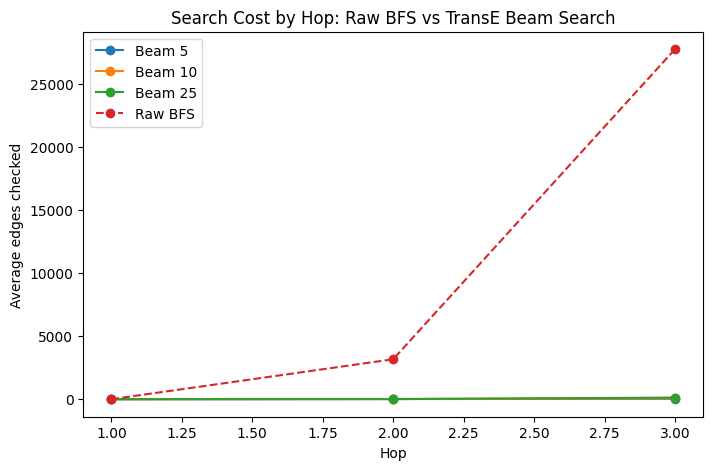

In [ ]:
#visualizing the cost savings in terms of number of expansions
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for beam_size in sorted(hop_comparison_df["beam_size"].unique()):
    sub = hop_comparison_df[hop_comparison_df["beam_size"] == beam_size]
    plt.plot(sub["hop"], sub["beam_avg_edges_checked"], marker="o", label=f"Beam {beam_size}")

bfs_sub = hop_comparison_df.drop_duplicates("hop")
plt.plot(
    bfs_sub["hop"],
    bfs_sub["bfs_avg_edges_checked"],
    marker="o",
    linestyle="--",
    label="Raw BFS"
)

plt.xlabel("Hop")
plt.ylabel("Average edges checked")
plt.title("Search Cost by Hop: Raw BFS vs TransE Beam Search")
plt.legend()
plt.show()

In [ ]:
# apart from edge reduction , we also get a big candidate reduction, table shows those numbers
candidate_table = hop_comparison_df[[
    "beam_size",
    "hop",
    "bfs_avg_output_candidates",
    "beam_avg_expanded_candidates",
    "beam_avg_kept_candidates",
]].copy()

candidate_table.columns = [
    "Beam size",
    "Hop",
    "BFS avg candidates",
    "Beam avg expanded",
    "Beam avg kept",
]

display(candidate_table)

,Beam size,Hop,BFS avg candidates,Beam avg expanded,Beam avg kept
0,5,1,8.950,1.062295,1.059016
1,5,2,2873.470,16.653409,4.278409
2,5,3,8839.325,4.391566,3.379518
3,10,1,8.950,1.062295,1.062295
4,10,2,2873.470,16.693182,7.056818
5,10,3,8839.325,7.487952,5.879518
6,25,1,8.950,1.062295,1.062295
7,25,2,2873.470,16.693182,11.829545
8,25,3,8839.325,12.415663,10.650602


In [ ]:
#final results showing hop-wise improvements
edge_table = hop_comparison_df[[
    "beam_size",
    "hop",
    "bfs_avg_edges_checked",
    "beam_avg_edges_checked",
]].copy()

edge_table["edge_reduction_%"] = (
    1 - edge_table["beam_avg_edges_checked"] / edge_table["bfs_avg_edges_checked"]
) * 100

edge_table.columns = [
    "Beam size",
    "Hop",
    "BFS avg edges checked",
    "Beam avg edges checked",
    "Edge reduction %",
]

display(edge_table)

,Beam size,Hop,BFS avg edges checked,Beam avg edges checked,Edge reduction %
0,5,1,9.615,9.698361,-0.866985
1,5,2,3178.090,22.789773,99.282910
2,5,3,27762.375,44.740964,99.838843
3,10,1,9.615,9.698361,-0.866985
4,10,2,3178.090,22.829545,99.281658
5,10,3,27762.375,80.409639,99.710365
6,25,1,9.615,9.698361,-0.866985
7,25,2,3178.090,22.829545,99.281658
8,25,3,27762.375,138.102410,99.502555


In [ ]:
# random test
row = qa3_paths_df[qa3_paths_df["relation_paths"].apply(lambda x: len(x) > 0)].iloc[0]

question = row["question"]
start = row["topic_entity"]
gold = row["answers"]
relation_path = row["relation_paths"][0]

print("Question:", question)
print("Start:", start)
print("Gold:", gold)
print("Relation path:", relation_path)

Question: the films that share directors with the film [Catch Me If You Can] were in which languages
Start: Catch Me If You Can
Gold: ['German', 'Polish', 'Mende', 'Japanese']
Relation path: ['directed_by', 'inv_directed_by', 'in_language']


In [ ]:
# building a graph out of the search itself, to plot later ( to visually see how much smaller the search is)
import networkx as nx

def build_raw_bfs_search_graph(G, start_entity, max_hops=3):
    H = nx.DiGraph()

    frontier = {start_entity}
    H.add_node(start_entity, depth=0)

    for hop in range(1, max_hops + 1):
        next_frontier = set()

        for node in frontier:
            if node not in G:
                continue

            for _, nbr, data in G.out_edges(node, data=True):
                H.add_node(nbr, depth=hop)
                H.add_edge(node, nbr, relation=data["relation"])
                next_frontier.add(nbr)

        frontier = next_frontier

        if not frontier:
            break

    return H

In [ ]:
#same idea as above, storing the beam search itself as a graph (basically a DAG)

def build_beam_search_graph(G, start_entity, relation_path, beam_size=5):
    H = nx.DiGraph()

    beam = [{
        "node": start_entity,
        "score": 0.0,
    }]

    H.add_node(start_entity, depth=0)

    for hop, rel in enumerate(relation_path, start=1):
        expanded = []

        for item in beam:
            current = item["node"]

            if current not in G:
                continue

            for _, nbr, data in G.out_edges(current, data=True):
                if data["relation"] != rel:
                    continue

                s = score_triple(current, rel, nbr)
                if s is None:
                    continue

                expanded.append({
                    "node": nbr,
                    "parent": current,
                    "score": item["score"] + s,
                })

        expanded.sort(key=lambda x: x["score"], reverse=True)
        beam = expanded[:beam_size]

        for x in expanded:
            H.add_node(x["node"], depth=hop)
            H.add_edge(x["parent"], x["node"], relation=rel)

        if not beam:
            break

    return H, beam

In [ ]:
# plotting the search DAGS from the previous two cells

import matplotlib.pyplot as plt
import random
import networkx as nx


def plot_layered_search_graph(
    H,
    title,
    gold=None,
    max_edges=1500,
    edge_width=0.25,
    edge_alpha=0.08,
    seed=42
):
    if gold is None:
        gold = []
    gold = set(gold)
    random.seed(seed)

    edges = list(H.edges())
    if len(edges) > max_edges:
        edges = random.sample(edges, max_edges)

    nodes = set()
    for u, v in edges:
        nodes.add(u)
        nodes.add(v)

    depths = nx.get_node_attributes(H, "depth")

    by_depth = {}
    for n in nodes:
        d = depths.get(n, 0)
        by_depth.setdefault(d, []).append(n)

    pos = {}
    for d, ns in by_depth.items():
        ns = sorted(ns)
        m = len(ns)
        for i, n in enumerate(ns):
            y = i - (m / 2)
            pos[n] = (d, y)

    plt.figure(figsize=(14, 8))

    # edges
    for u, v in edges:
        if u in pos and v in pos:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            plt.plot([x1, x2], [y1, y2],
                     linewidth=edge_width,
                     alpha=edge_alpha)

    # nodes
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    plt.scatter(xs, ys, s=4, alpha=0.6)

    # highlight gold/true entities
    gold_nodes = [n for n in nodes if n in gold]
    if gold_nodes:
        gx = [pos[n][0] for n in gold_nodes]
        gy = [pos[n][1] for n in gold_nodes]
        plt.scatter(gx, gy, s=40)
        for n in gold_nodes:
            plt.text(pos[n][0] + 0.03, pos[n][1], n, fontsize=9)

    plt.xticks(sorted(set(depths.values())))
    plt.xlabel("Hop")
    plt.ylabel("Nodes within hop")
    plt.title(title)
    plt.show()

In [ ]:
row = qa3_paths_df.iloc[0]

question = row["question"]
start = row["topic_entity"]
gold = row["answers"]
relation_path = row["relation_paths"][0]

print("Question:", question)
print("Path:", relation_path)

Question: the films that share directors with the film [Catch Me If You Can] were in which languages
Path: ['directed_by', 'inv_directed_by', 'in_language']


In [ ]:
raw_H = build_raw_bfs_search_graph(G, start, max_hops=3)

beam_H, final_beam = build_beam_search_graph(
    G,
    start,
    relation_path,
    beam_size=5
)

print("Raw BFS:", raw_H.number_of_nodes(), "nodes")
print("Beam:", beam_H.number_of_nodes(), "nodes")

Raw BFS: 18673 nodes
Beam: 30 nodes


In [ ]:
# need to do sampling on the BFS search, because matplotlib doesn't complete rendering on the full search tree due to it's large size
def sample_graph_edges(H, max_edges=300, seed=42):
    import random
    import networkx as nx

    random.seed(seed)

    edges = list(H.edges(data=True))
    sampled_edges = random.sample(edges, min(max_edges, len(edges)))

    S = nx.DiGraph()

    for u, v, d in sampled_edges:
        S.add_node(u, depth=H.nodes[u].get("depth"))
        S.add_node(v, depth=H.nodes[v].get("depth"))
        S.add_edge(u, v, **d)

    return S

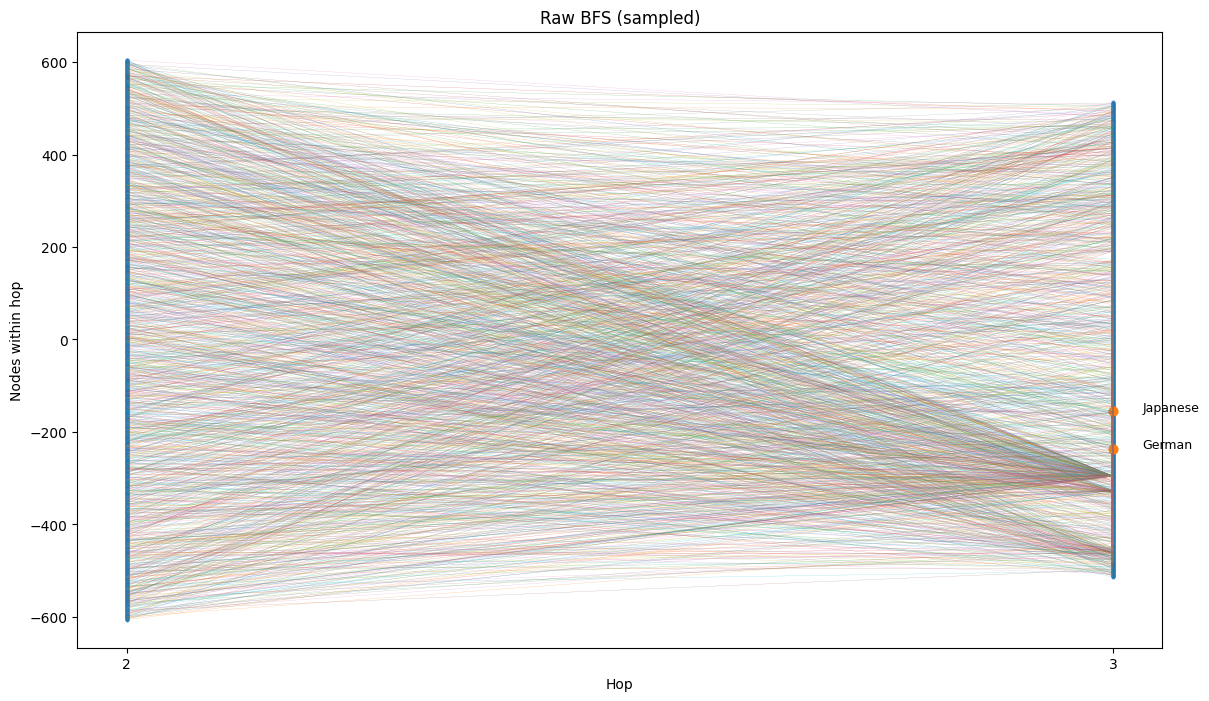

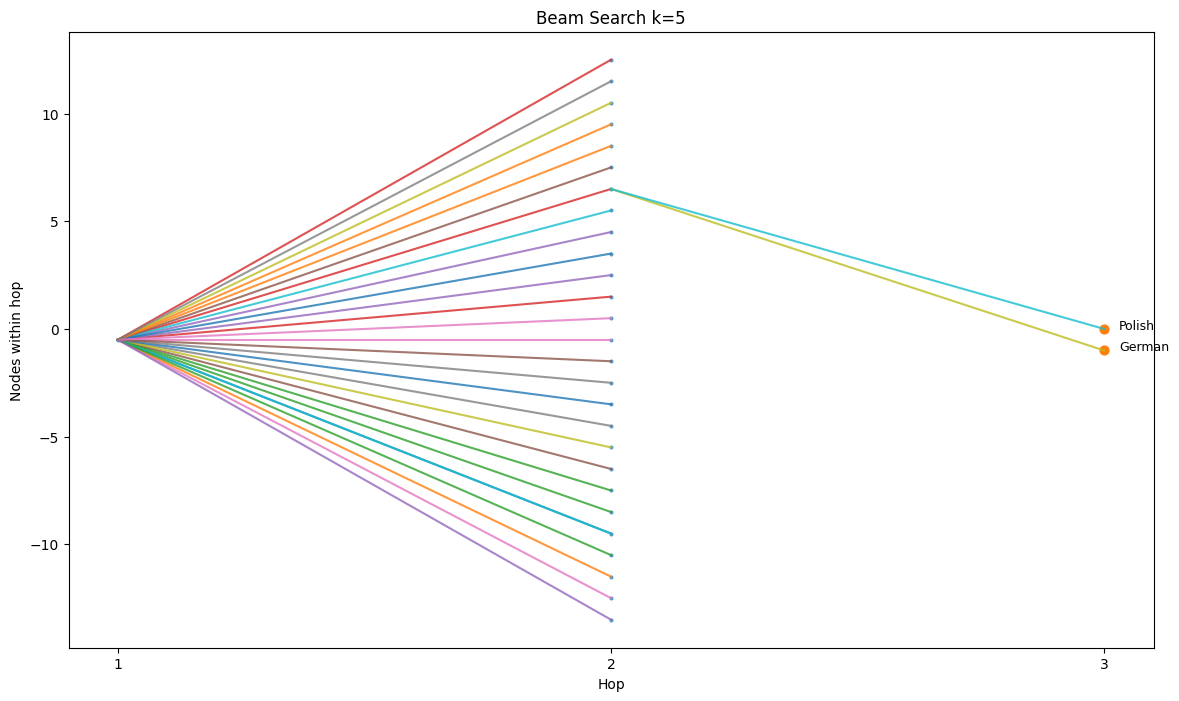

In [ ]:
#finally checking how much smaller the beam search tree is compared even to the sampled BFS tree (original is much bigger)
plot_layered_search_graph(
    raw_H,
    "Raw BFS (sampled)",
    gold=gold,
    max_edges=1500,
    edge_width=0.2,
    edge_alpha=0.5,
)
plot_layered_search_graph(
    beam_H,
    "Beam Search k=5",
    gold=gold,
    max_edges=999999,
    edge_width=1.5,
    edge_alpha=0.8,
)